## Student Name: Sanyam Goel
# Assignment 8

## Word Embeddings

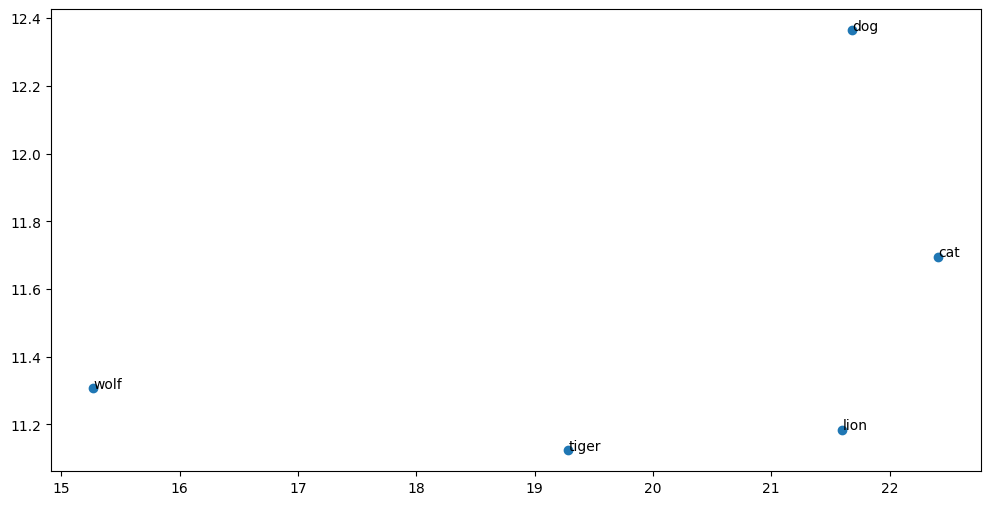

In [1]:
import numpy as np
from umap import UMAP
import matplotlib.pyplot as plt
import seaborn as sns

def load_glove_vectors(path:str)-> dict[str, np.ndarray]:

    """
    This method loads glove vectors and creates embedding map for each word
    
     Args:
        path (str): path to file.

    Returns:
        DataFrame: The created data frame.
    """
    
    embeddings: dict[str, np.ndarray] = {} 
    
    with open(path, "r", encoding="utf8") as f: 
        
        for line in f: 
            parts = line.strip().split() 
            word = parts[0] 
            vector_for_word = np.array(parts[1:], dtype=np.float32) 
            embeddings[word] = vector_for_word 
    
    return embeddings

def cosine_similarity(first_vector: np.ndarray, second_vector: np.ndarray) -> np.float32: 

    """
    This method calculates cosine similarties and utilizes numpy library 
    
     Args:
        first_vector (np.ndarray): vector for word
        second_vector (np.ndarray): vector for word
        
    Returns:
        cosine (np.float32)
    """
    
    return np.dot(first_vector, second_vector) / (np.linalg.norm(first_vector) * np.linalg.norm(second_vector))

def most_similar_words(word, embeddings, top_word_count): 

    """
    This method calculates most similar words
    
     Args:
        first_vector (np.ndarray): vector for word
        second_vector (np.ndarray): vector for word
        
    Returns:
        cosine (np.float32)
    """
    
    if word not in embeddings: 
        raise ValueError(f"{word} not found in vocabulary") 
        
    target_vector = embeddings[word] 
    
    similarities: dict[str, float] = {} 
        
    for other_word, vector in embeddings.items(): 

        #ignore cosnine similarity calculation for same word as its going to be 1
        if other_word == word: 
            
            continue 
            
        similarities[other_word] = cosine_similarity(target_vector, vector)  
        
    sorted_words = sorted(similarities.items(), key=lambda item: item[1], reverse=True) 
    
    return sorted_words[:top_word_count]

def words_to_matrix(words: List[str], embeddings: Dict[str, np.ndarray]) -> np.ndarray: 

    """
    This method appends all word vectors into a matrix
    
     Args:
        first_vector (np.ndarray): vector for word
        second_vector (np.ndarray): vector for word
        
    Returns:
        cosine (np.float32)
    """
    
    vectors: list[np.ndarray] = [] 
   
    for word in words: 
        
        if word not in embeddings: 
            raise ValueError(f"'{word}' not found in vocabulary") 
        vectors.append(embeddings[word]) 
        
    return np.vstack(vectors)

def plot_word_embeddings(words,vectors,num_neighbors=2):
    
    """
    Utility function to do a 2d plot of word-embeddings with annotations.
    
    param words: list of words
    param vectors: array of word embeddings corresponding to the list of words
    param num_neighbors: number of neighbors to consider in the UMAP projection
    """
    # Project the 50d vectors to a 2d space
    V_umap = UMAP(n_neighbors=num_neighbors,min_dist=0.2).fit_transform(vectors)
    
    fig= plt.figure(figsize=(12,6))

    plt.scatter(V_umap[:, 0], V_umap[:, 1])
    for i, word in enumerate(words):
        plt.annotate(word, xy=(V_umap[i, 0], V_umap[i, 1]))
    plt.show()

    
glove = load_glove_vectors("assignment-8/data/glove.6B/glove.6B.50d.txt")

most_similar_words("king", glove, 20)

words = ["cat", "dog", "lion", "tiger", "wolf"] 

vecs = words_to_matrix(words, glove)

plot_word_embeddings(words, vecs)

## Inside AirBnB

### Part 1

In [2]:
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 

 
def load_data_frame(path:str)-> pd.DataFrame:

    """
    Read csv file to create dataFrame
    
    Args:
        path (str): path to file.
    Returns:
        DataFrame: The created data frame.
        
    """
    return pd.read_csv(path)

def plot_listing_reviews_per_year(df: pd.DataFrame):

    """
    This method plots reviews per year histogram (to acomodate result of all listings)

    Args:
        df(DataFrame): DataFrame for listings
        
    Returns:
        None
        
    """
    
    df['reviews_per_year'] = df['reviews_per_month'].fillna(0) * 12
    listing_reviews_per_year =  df['reviews_per_year'].sum()
    
    print(f'Total reviews of all listings per year: {listing_reviews_per_year}')

    plt.figure(figsize=(8, 5))
    sns.histplot(data=df, x='reviews_per_year', bins=40, kde=True)
    plt.title('Reviews per year for each listing')
    plt.xlabel('Reviews per Year') 
    plt.ylabel('Count of Listings') 
    plt.tight_layout()


def plot_number_of_listings_per_room_type(df: pd.DataFrame)-> None:

    """
    This method plots number of listings per room types

    Args:
        df(DataFrame): DataFrame for listings
        
    Returns:
        None
        
    """
    
    room_per_listing = df['room_type'].value_counts().reset_index() 
    room_per_listing.columns = ['room_type', 'count'] 
    
    plt.figure(figsize=(8, 5)) 
    sns.barplot(data=room_per_listing, x='room_type', y='count') 
    plt.title("Average number of reviews") 
    plt.xlabel("Room Type") 
    plt.ylabel("Average number  of Reviews") 
    plt.tight_layout()

def plot_number_of_booking_per_property_types(df: pd.DataFrame) -> None:

    """
    This method plots number of bookings per property type

    Args:
        df(DataFrame): DataFrame for listings
        
    Returns:
        None
        
    """
    
    bookings_per_room_type = df['property_type'].value_counts().reset_index() 
    bookings_per_room_type.columns = ['property_type', 'count'] 
    
    plt.figure(figsize=(12, 5)) 
    sns.barplot(data=bookings_per_room_type, x='property_type', y='count') 
    plt.title("Number of bookings per Property Type") 
    plt.xlabel("Property Type") 
    plt.ylabel("Number of Bookings") 
    plt.tight_layout() 
    plt.xticks(rotation=90)

def plot_avg_num_of_review_per_room_type(df: pd.DataFrame) -> None:

    """
    This method plots average number of reviews per room type

    Args:
        df(DataFrame): DataFrame for listings
        
    Returns:
        None
    """
    
    avgerage_review_per_room_type = (df.groupby('room_type')['number_of_reviews']
        .mean()
        .reset_index())

    plt.figure(figsize=(12, 5)) 
    sns.barplot(data=avgerage_review_per_room_type, x='room_type', y='number_of_reviews', order= avgerage_review_per_room_type['number_of_reviews']) 
    plt.title("Number of bookings per Property Type") 
    plt.xlabel("Room Type") 
    plt.ylabel("Averafe Number of Bookings") 
    plt.tight_layout() 

def plot_total_number_of_bookings_per_neighbourhood(df: pd.DataFrame) -> None:

    """
    This method plots total number of bookings per neighbourhood

    Args:
        df(DataFrame): DataFrame for listings
        
    Returns:
        None
    """
    
    bookings_per_neighbourhood = (df.groupby('neighbourhood_cleansed')['number_of_reviews']
            .sum()
            .reset_index()
            .rename(columns={'neighbourhood_cleansed': 'neighbourhood', 'number_of_reviews':'total_bookings'})
            .sort_values('total_bookings', ascending= False)
            .head(10))
    
    sns.barplot(data=bookings_per_neighbourhood, x='neighbourhood', y='total_bookings')
    plt.xticks(rotation=90)

def plot_average_number_of_listings_per_host(df: pd.DataFrame) -> None:

    """
    This method plots average number of listings per host

    Args:
        df(DataFrame): DataFrame for listings
        
    Returns:
        None
    """
    
    host_listings = (df.groupby('host_id')
        .size()
        .reset_index(name='num_of_listings'))
    
    average_number_of_listings = host_listings['num_of_listings'].mean()

    print(f'Average number of listing per host %f',average_number_of_listings)
    
    plt.figure(figsize=(8, 5)) 
    sns.histplot( data=host_listings, x='num_of_listings', binwidth=1) 
    plt.title("Distribution of Number of Listings per Host") 
    plt.xlabel("Number of Listings") 
    plt.ylabel("Frequency") 
    plt.tight_layout() 
    plt.show()

def plot_total_number_of_reviews_per_listing(df:pd.DataFrame) -> None:

    """
    This method plots total number of reviews per listing

    Args:
        df(DataFrame): DataFrame for listings
        
    Returns:
        None
    """
    
    total_reviews = df['number_of_reviews']
    sns.histplot( data=df, x='number_of_reviews', bins=40) 
    plt.title("Distribution of Total Number of Reviews per Listing") 
    plt.xlabel("Total Reviews") 
    plt.ylabel("Frequency") 
    plt.tight_layout() 
    plt.show()

def calculate_total_number_of_reviews_by_flag(df:pd.DataFrame) -> None:

    """
    This method plots total number of reviews by instant_bookable flag

    Args:
        df(DataFrame): DataFrame for listings
        
    Returns:
        None
    """
    
    reviews_by_flag = (df.groupby('instant_bookable')['number_of_reviews']
        .sum()
        .reset_index()
        .rename(columns={'number_of_reviews': 'total_reviews'}) ) 
    print(reviews_by_flag)

def plot_10_most_common_10_least_common_amenities(df: pd.DataFrame) -> None:
 
    """
    This method plots 1o most common and 10 least common amenities

    Args:
        df(DataFrame): DataFrame for listings
        
    Returns:
        None
    """
    
    df['amenities'] = df['amenities'].apply(lambda list_amenities: eval(list_amenities) if isinstance(list_amenities, str) else list_amenities)
    amenities = df.explode('amenities')
    ammenities_count= (amenities['amenities'].value_counts()
        .reset_index()
        .rename(columns={'amenities': 'amenity'})
        .sort_values(ascending = False, by = 'count'))

    most_frequent_10= ammenities_count.head(10)
    least_frequent_10= ammenities_count.tail(10)

    print('Top 10 Most Frequent Amenities: \n',most_frequent_10)

    print('Bottom 10 Least Frequent Amenities: \n',least_frequent_10)


    sns.barplot( data=most_frequent_10, x='amenity', y='count')
    plt.title("Top 10 Most Frequent Amenities") 
    plt.xticks(rotation=90) 
    plt.show()

    sns.barplot( data=least_frequent_10, x='amenity', y='count')
    plt.title("Bottom 10 Least Frequent Amenities") 
    plt.xticks(rotation=90) 
    plt.show()

Total reviews of all listings per year: 138855.12
Average number of listing per host %f 1.1555309462286207


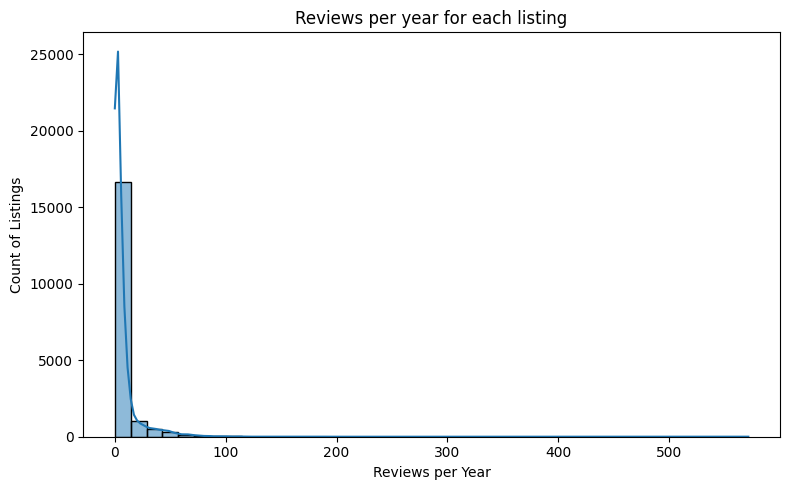

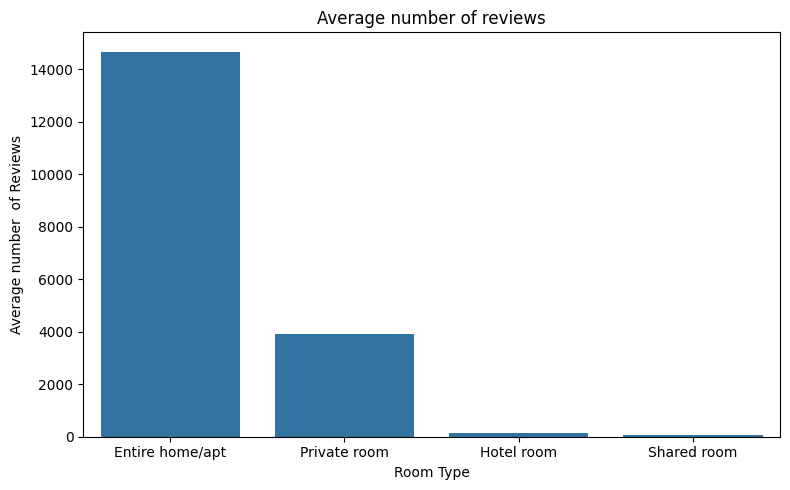

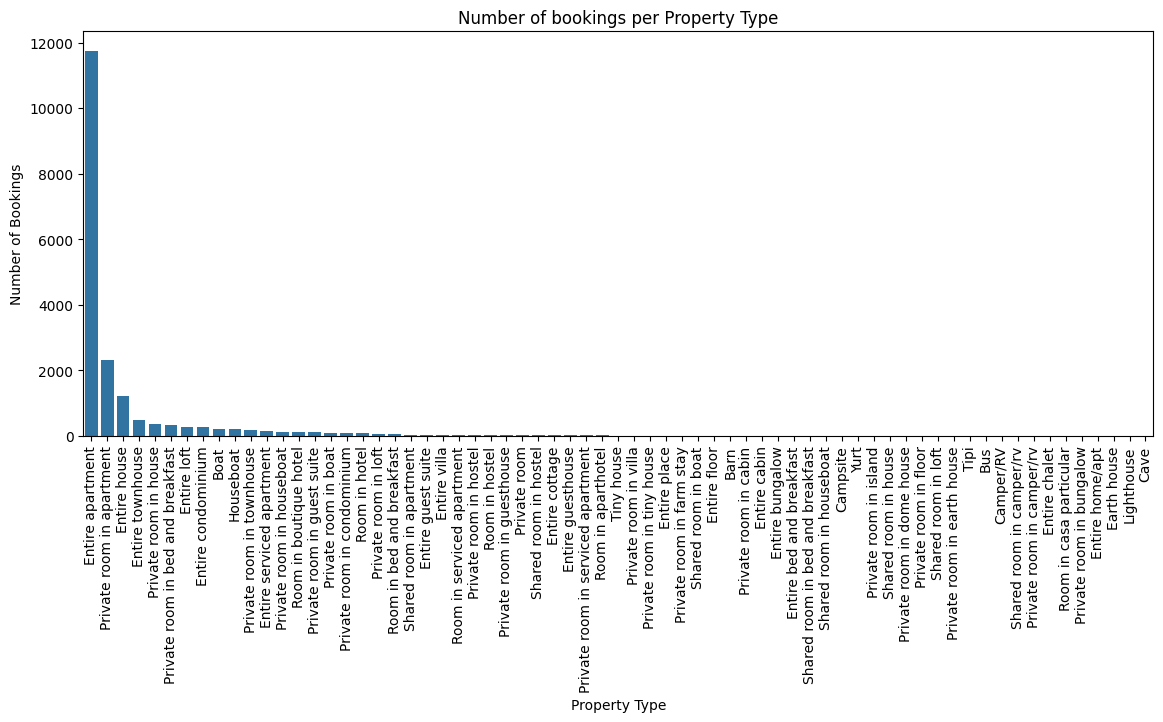

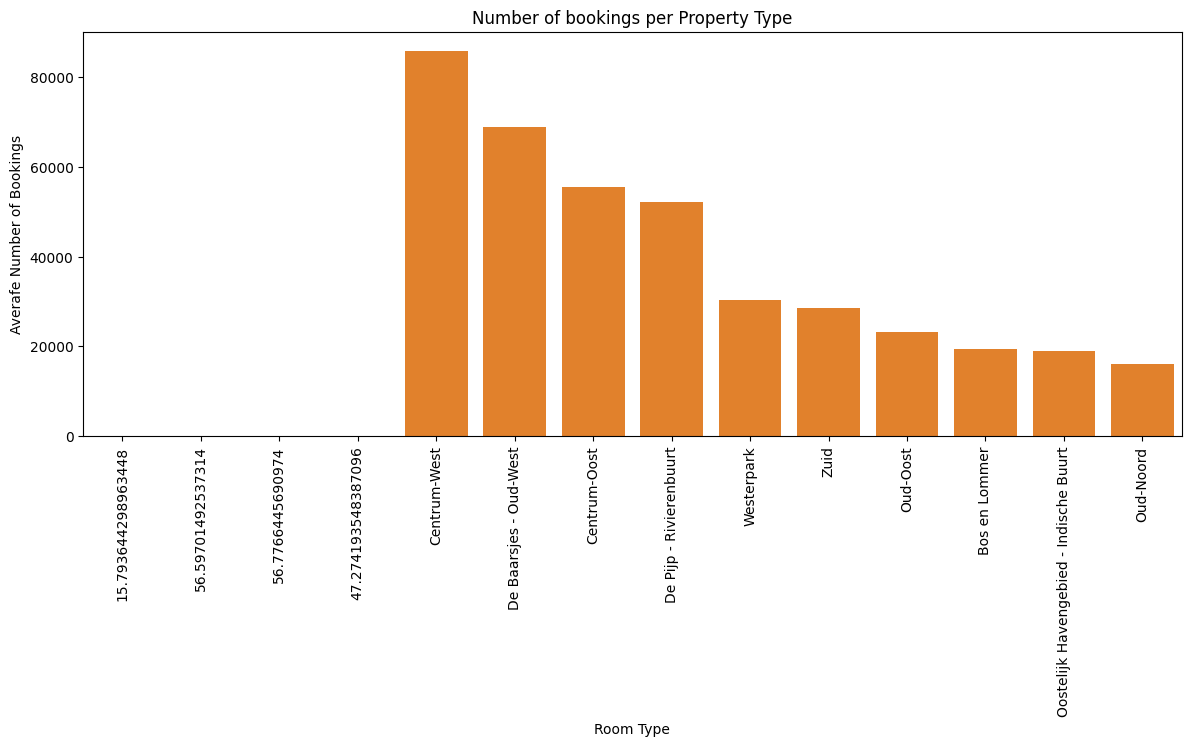

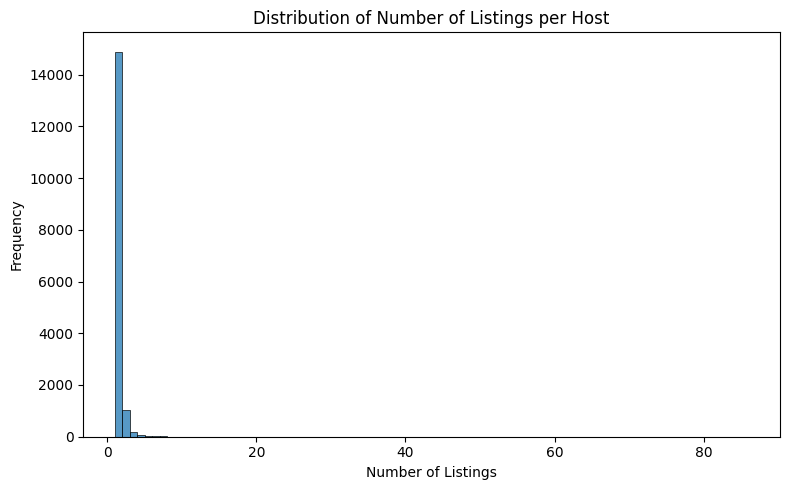

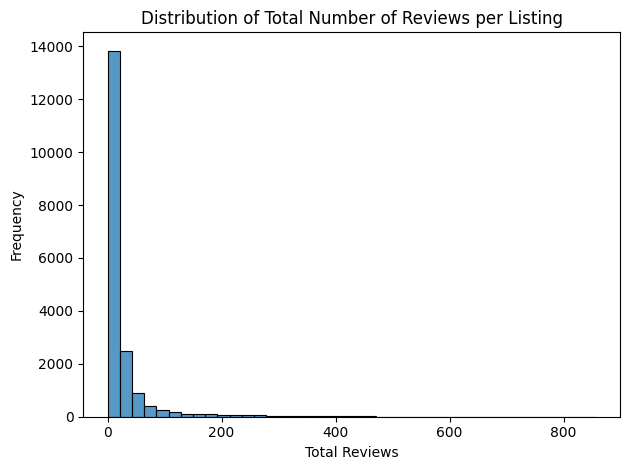

  instant_bookable  total_reviews
0                f         296071
1                t         168720
Top 10 Most Frequent Amenities: 
                      amenity  count
0                       Wifi  18338
1                    Heating  18137
2                 Essentials  18097
3                    Kitchen  16714
4                Smoke alarm  15093
5                         TV  14406
6                     Washer  14160
7                    Hangers  13437
8                       Iron  12682
9  Laptop-friendly workspace  12677
Bottom 10 Least Frequent Amenities: 
                                                amenity  count
159  TV with Netflix, HBO Max, Chromecast, premium ...      1
158                               Siemens refrigerator      1
157                            Siemens induction stove      1
156                                       Siemens oven      1
155          Sonos sound system with Bluetooth and aux      1
154                    Stainless steel induction stove    

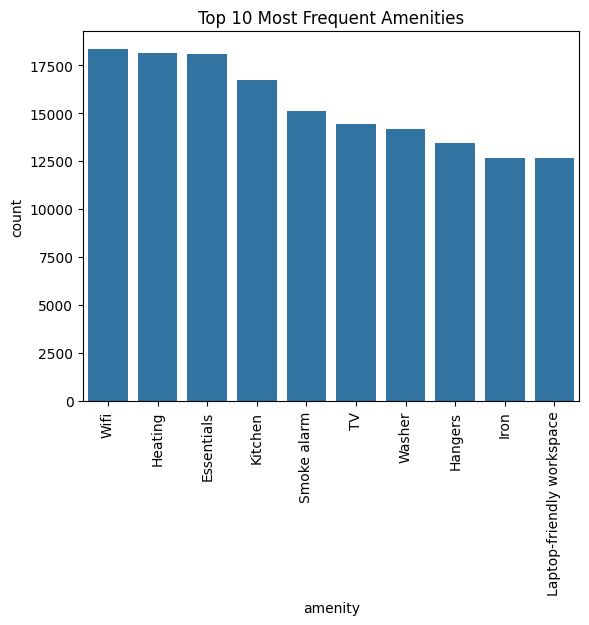

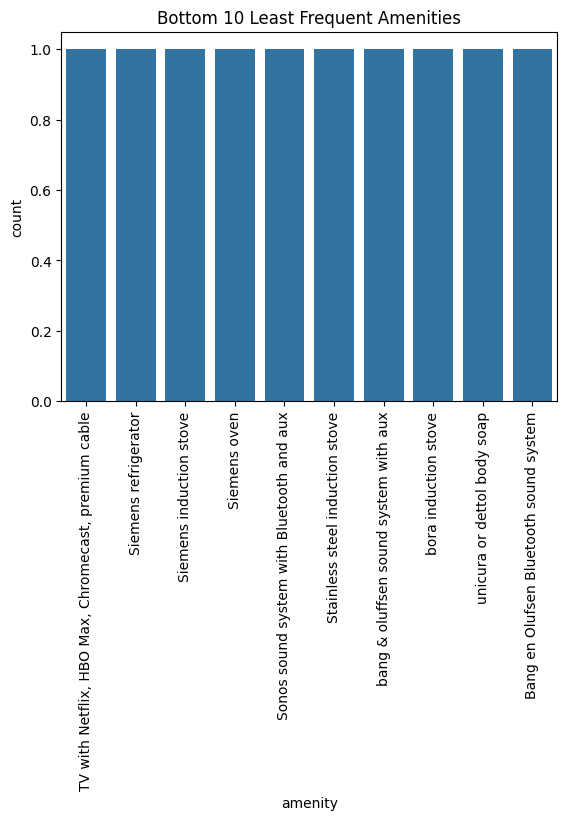

In [3]:
df_listings = load_data_frame("assignment-8/data/listings_Amsterdam.csv")
plot_listing_reviews_per_year(df_listings)
plot_number_of_listings_per_room_type(df_listings)
plot_number_of_booking_per_property_types(df_listings)
plot_avg_num_of_review_per_room_type(df_listings)
plot_total_number_of_bookings_per_neighbourhood(df_listings)
plot_average_number_of_listings_per_host(df_listings)
plot_total_number_of_reviews_per_listing(df_listings)
calculate_total_number_of_reviews_by_flag(df_listings)
plot_10_most_common_10_least_common_amenities(df_listings)

## Part 2

## This plot helps in finding the highest average review length for top X listings 

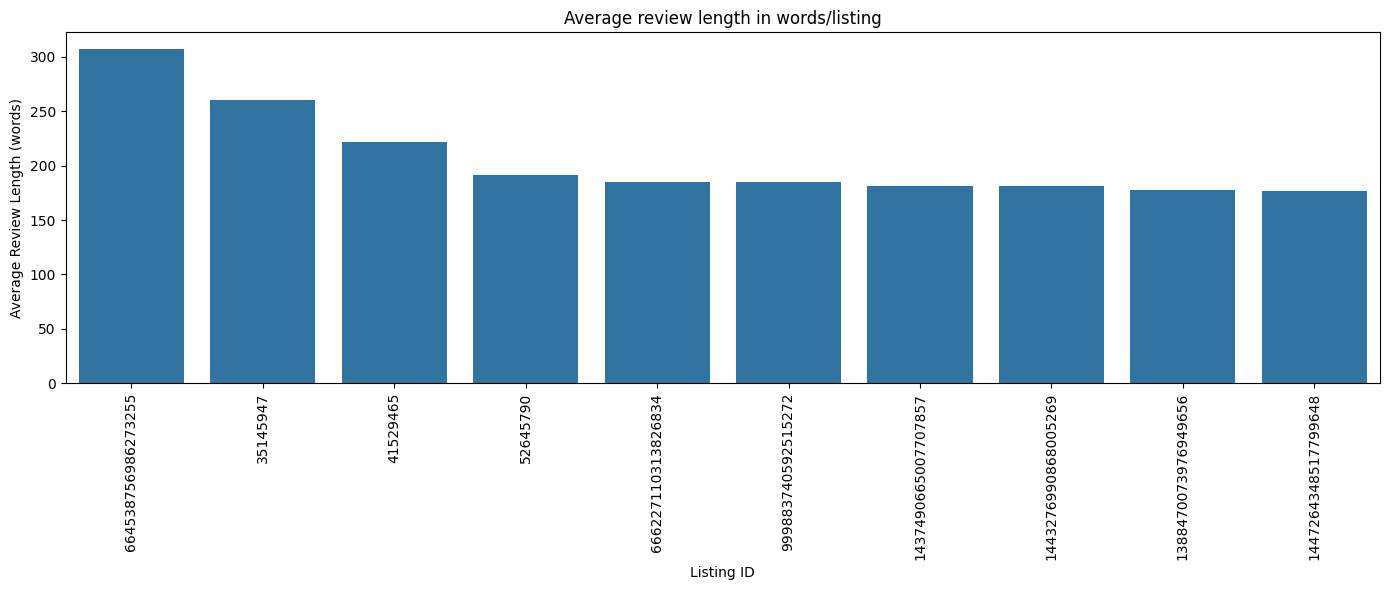

In [4]:
def plot_top_average_review_length(df:pd.DataFrame, number_of_top_listings:int) -> None:

    
    """
    This method plots average review length

    Args:
        df(DataFrame): DataFrame for geojson
        number_of_top_listings (int): Number of listings to be displayed
        
    Returns:
        None
        
    """
    
    avg_length_per_listing = (df.groupby('listing_id')['comments']
        .apply(lambda comment: comment.str.split().str.len().mean())
        .reset_index(name='avg_length')
        .sort_values(by='avg_length', ascending=False).head(number_of_top_listings))
    
    plt.figure(figsize=(14, 6)) 
    sns.barplot( data=avg_length_per_listing, x='listing_id', y='avg_length', order=avg_length_per_listing['listing_id'])
    plt.xticks(rotation=90) 
    plt.title("Average review length in words/listing") 
    plt.xlabel("Listing ID") 
    plt.ylabel("Average Review Length (words)") 
    plt.tight_layout() 
    plt.show() 


df_reviews = load_data_frame("assignment-8/data/reviews_Amsterdam.csv")

plot_top_average_review_length(df_reviews, 10)

### This plot helps in identifying average reviews per year for a neighbourhood

Average Reviews per Neighbourhood
                     neighbourhood_cleansed  avg_reviews
5                             Centrum-West    12.638817
6                   De Aker - Nieuw Sloten    11.177143
4                             Centrum-Oost    10.287508
0                          Bijlmer-Centrum     9.752000
9                    Gaasperdam - Driemond     9.483000
1                             Bijlmer-Oost     8.684848
16                               Oud-Noord     7.894949
18                             Slotervaart     7.893980
15                                  Osdorp     7.891875
10                 Geuzenveld - Slotermeer     7.415775
13                              Noord-West     7.253264
12                              Noord-Oost     6.654382
21                                    Zuid     6.348468
7                   De Baarsjes - Oud-West     6.305633
14  Oostelijk Havengebied - Indische Buurt     6.286011
8                  De Pijp - Rivierenbuurt     6.197365
20           

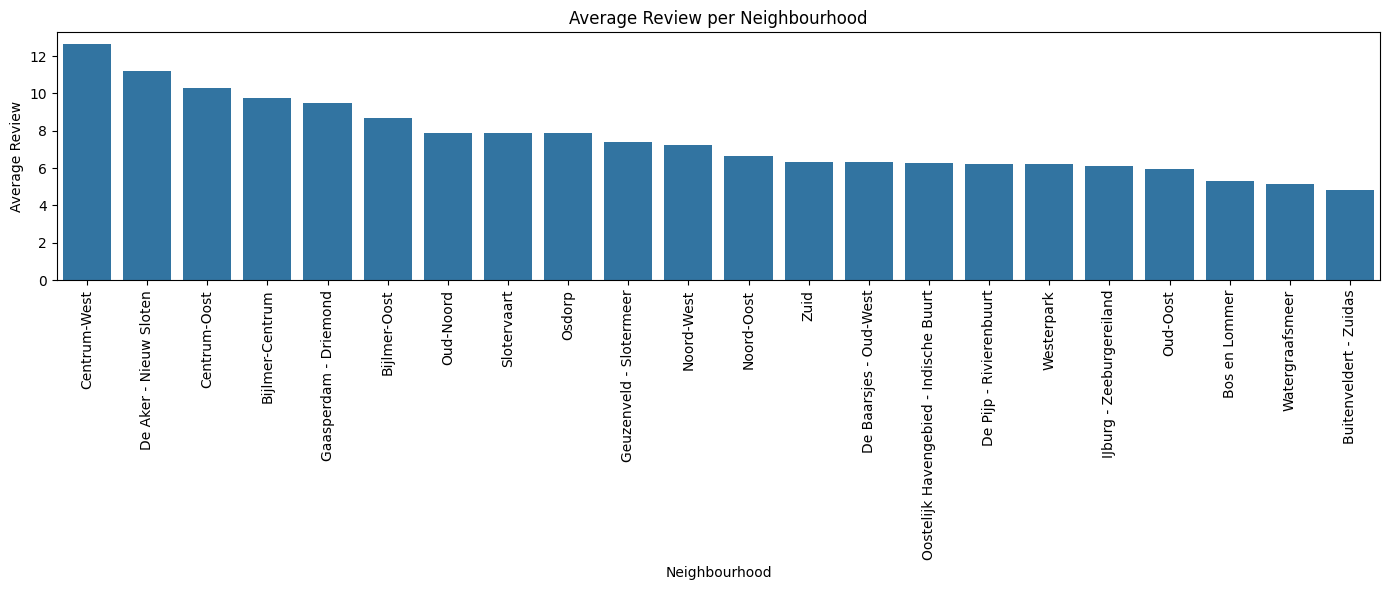

In [5]:
def plot_average_review_per_neighbourhood(df_neighbourhood: pd.DataFrame, df_listings: pd.DataFrame)-> None:

    """
    This method plots average review per neighbourhoods

    Args:
        gdf_dataframe (DataFrame): DataFrame for geojson
        df_merged_listings_neighbourhood: DataFrame of neighbourhoods
        
    Returns:
        None
        
    """
    
    df_merged_listings_neighbourhood = df_listings.merge(df_neighbourhood, left_on='neighbourhood_cleansed', right_on='neighbourhood', how='left')
    
    avg_reviews_per_neighbourhood = ( df_merged_listings_neighbourhood.groupby('neighbourhood_cleansed')['reviews_per_year']
    .mean()
    .reset_index(name='avg_reviews')
    .sort_values('avg_reviews', ascending=False))
    
    print(f'Average Reviews per Neighbourhood\n {avg_reviews_per_neighbourhood}')
    
    plt.figure(figsize=(14, 6)) 
    
    sns.barplot( data=avg_reviews_per_neighbourhood, 
                 x='neighbourhood_cleansed', 
                 y='avg_reviews', 
                 order=avg_reviews_per_neighbourhood['neighbourhood_cleansed'] ) 
    
    plt.xticks(rotation=90) 
    plt.title("Average Review per Neighbourhood") 
    plt.xlabel("Neighbourhood") 
    plt.ylabel("Average Review") 
    plt.tight_layout()


df_neighbourhood = pd.read_csv("assignment-8/data/neighbourhoods.csv")
plot_average_review_per_neighbourhood(df_neighbourhood,df_listings)


<Figure size 1200x1000 with 0 Axes>

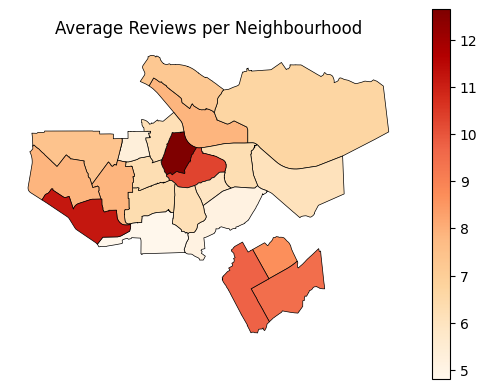

In [6]:
import geopandas as gpd 

def read_geojson(path: str)-> pd.DataFrame:

    """
    Read geojson file
    installation required pip3 install geopandas

    Args:
        path (str): path to file.

    Returns:
        DataFrame: The created data frame.
        
    """
    return gpd.read_file(path) 
    
def plot_headmap_of_neighbourhood_avg_reviews(gdf_dataframe: pd.DataFrame, df_merged_listings_neighbourhood: pd.DataFrame)-> None:

    """
    This method creates the heatmap per neighbourhood and helps to identify hight 
    concentration areas according to bookings done

    Args:
        gdf_dataframe (DataFrame): DataFrame for geojson
        df_merged_listings_neighbourhood: DataFrame of neighbourhoods
        
    Returns:
        None
        
    """
    
    metric_df = ( df_merged_listings_neighbourhood
        .groupby("neighbourhood_cleansed")["reviews_per_year"]
        .mean()
        .reset_index(name="avg_reviews") )
    
    metric_df = metric_df.rename(columns={ "neighbourhood_cleansed": "neighbourhood" })
    gdf_merged = gdf_dataframe.merge(metric_df, on="neighbourhood", how="left")
    
    plt.figure(figsize=(12, 10)) 
    gdf_merged.plot( column="avg_reviews", cmap="OrRd", legend=True, edgecolor="black", linewidth=0.5 ) 
    plt.title("Average Reviews per Neighbourhood") 
    plt.axis("off") 
    plt.show()

gdf_dataframe =  read_geojson("assignment-8/data/neighbourhoods.geojson")
df_merged_listings_neighbourhood = df_listings.merge(df_neighbourhood, left_on='neighbourhood_cleansed', right_on='neighbourhood', how='left')
plot_headmap_of_neighbourhood_avg_reviews(gdf_dataframe, df_merged_listings_neighbourhood)